In [3]:
import seaborn as sns

df = sns.load_dataset("iris")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [4]:
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [5]:
import pandas as pd 
df['species'] = df['species'].map({
    'setosa': 0,
    'versicolor': 1,
    'virginica': 2
})
df.sample(5) # sample is used to get a random sample of the data

,sepal_length,sepal_width,petal_length,petal_width,species
98,5.1,2.5,3.0,1.1,1
8,4.4,2.9,1.4,0.2,0
95,5.7,3.0,4.2,1.2,1
18,5.7,3.8,1.7,0.3,0
32,5.2,4.1,1.5,0.1,0


In [6]:
X = df.drop(columns=['species'], axis=1)
y = df['species']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)
# stratify=y ensures that the split is stratified, meaning that the proportion of each class in the target variable is maintained in both the training and test sets.
# random_state=42 ensures that the split is reproducible.
y_train.value_counts()

species
0    45
2    45
1    45
Name: count, dtype: int64

In [16]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(max_depth=2)
# dt_clf.fit(X_train, y_train)
# y_pred = dt_clf.predict(X_test)
dt_clf.fit(X_train[['petal_length', 'sepal_length']], y_train)
y_pred = dt_clf.predict(X_test[['petal_length', 'sepal_length']])

In [8]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)

print(f"{accuracy_score(y_test, y_pred) = }")
# print(f"{precision_score(y_test, y_pred) = }")
# print(f"{recall_score(y_test, y_pred) = }")
# print(f"{f1_score(y_test, y_pred) = }")

accuracy_score(y_test, y_pred) = 0.9333333333333333


In [9]:
y_train.unique()

array([0, 2, 1])

In [10]:
# from sklearn.tree import export_graphviz
# export_graphviz(
#     dt_clf,
#     out_file='iris_tree.dot',
#     feature_names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
#     class_names=df['species'].unique().astype(str),
#     rounded=True,
#     filled=True
# )

In [11]:
! pip install graphviz


In [12]:
!  pip install mlxtend

d:\anoconda\envs\tech-axis\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


<Axes: >

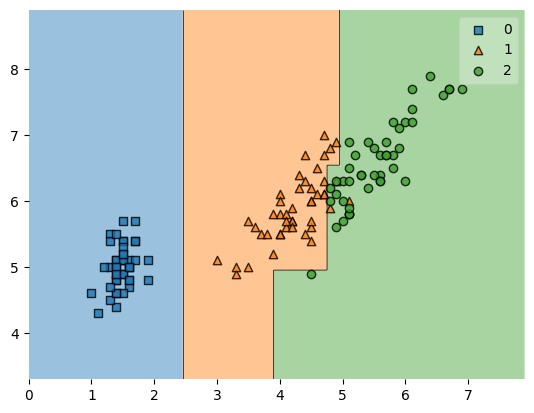

In [13]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(
    X_train[['petal_length', 'sepal_length']].to_numpy(),
    y_train.to_numpy(),
    clf=dt_clf,
    # legend=2
)
# if max_depth not set, overfitting issue occurs and the decision boundary is very complex and fits the training data too closely. 
# overfitted model as the decision boundary is very complex and fits the training data too closely.

[Text(0.4, 0.8333333333333334, 'sepal_length <= 2.45\ngini = 0.667\nsamples = 135\nvalue = [45, 45, 45]\nclass = setosa'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 45\nvalue = [45, 0, 0]\nclass = setosa'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'sepal_length <= 4.75\ngini = 0.5\nsamples = 90\nvalue = [0, 45, 45]\nclass = versicolor'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.048\nsamples = 41\nvalue = [0, 40, 1]\nclass = versicolor'),
 Text(0.8, 0.16666666666666666, 'gini = 0.183\nsamples = 49\nvalue = [0, 5, 44]\nclass = virginica')]

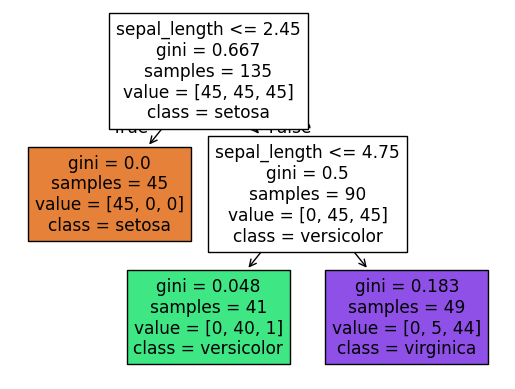

In [17]:
from sklearn import tree
tree.plot_tree(
    dt_clf,
    filled=True,
    feature_names= ['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
    class_names=['setosa', 'versicolor', 'virginica']
)

In [18]:
# from graphviz import Source
# Source.from_file('iris_tree.dot')

## Gini Impurity
- It tells how much mixed up the classes are in a group of data points.
- Gini = 1 - sum of square of probabilities of different classes
- Gini = 0 -> Pure group consisting data points of single class
- Gini > 0 -> Impure group consisting data points more than 1 class.
- Lowest Gini = 0
- Highest Gini = 1- (1/N), where N is the number of class.

## Entropy Impurity
- It measures the uncertainty/randomness in the group of data points.
- Entropy = negative sum of product of probability and log base 2 of probability 
- Entropy = 0 -> Pure
- Entropy > 0 -> Impure

### Example 
basket A - All red balloons 
basket B - 2 red balloons and 2 blue balloons 
basket C - 1 red, 1 blue, 1 green
basket D- 90 red, 2 blue

Gini = 1 - sum of square of probabilities of different classes
------------------------
- Basket A: 
    - P_red = 6/6 = 1
    - Gini = 1 - (1 ** 2) = 1 - 1 = 0 
    - Entropy = - (1 * log2(1)) = 
- Basket B:
    - P_red = 2/4 = 0.5 
    - P_blue = 2/4 = 0.5
    - Gini = 1 - (0.5 ** 2 + 0.5 ** 2) = 1 - (0.25 + 0.25) = 0.5
    - Entropy = -(0.5 * log2(0.5) + 0.5 * log2(0.5)) = 1
- Basket C: 
    - P_red: 1/3 = 0.3333
    - P_blue: 1/3 = 0.3333
    - P_green: 1/3 = 0.3333 
    - Gini = 1-(0.33 ** 2 + 0.33 ** 2 + 0.33 ** 2) = 1 - 0.3267 = 0.6733
    - Entropy = - (0.33 * log2(0.33) + 0.33 * log2(0.33)+ 0.33 * log2(0.33)) = 1.5834
- Basket D:
    - P_red = 90 /92 = 0.978
    - P_blue = 2/92 = 0.022
    - Gini = 1- (0.978 ** 2 + 0.022 ** 2) = 0.043
    - Entropy = - (0.978 * log2(0.978) + 0.022 * log2(0.022)) = 0.1525


In [22]:
import numpy as np
-((0.978 * np.log2(0.978) + 0.022 * np.log2(0.022)))

np.float64(0.15252732850878192)